In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity
from scipy.stats import norm

In [4]:
def draw_gaussian_mixture(m1,sigma1,m2,sigma2,clust1_proba,sample_size):
    sample=np.zeros(sample_size)
    for i in range(sample_size):
        x=np.random.uniform(0,1)
        if x<clust1_proba:
            sample[i]=(np.random.normal(m1,sigma1))
        else:
            sample[i]=(np.random.normal(m2,sigma2))
    return sample
def fit_kde(sample,kernel,bandwidth):
    sample=np.array(sample)
    sample=sample.reshape(-1,1)
    kde=KernelDensity(kernel=kernel,bandwidth=bandwidth)
    kde.fit(sample)
    return kde
def mixture_density(x,loc1,scale1,loc2,scale2,clust1_proba):
    return clust1_proba * norm.pdf(x, loc=loc1, scale=scale1) + (1-clust1_proba) * norm.pdf(x, loc=loc2, scale=scale2)

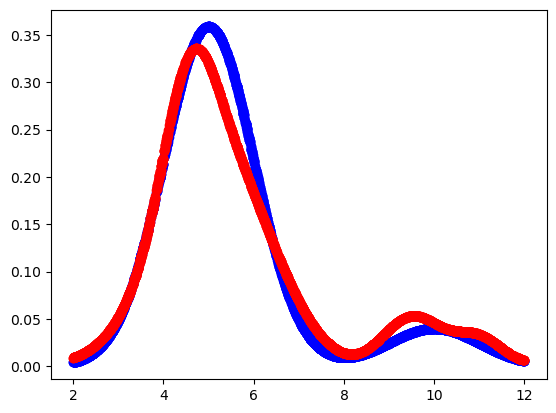

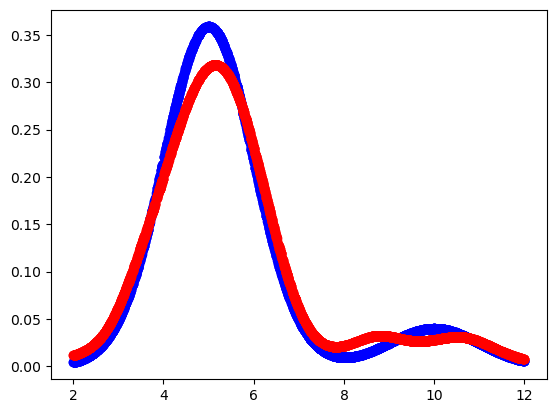

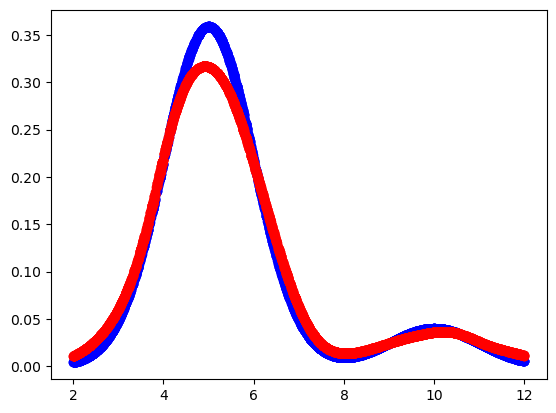

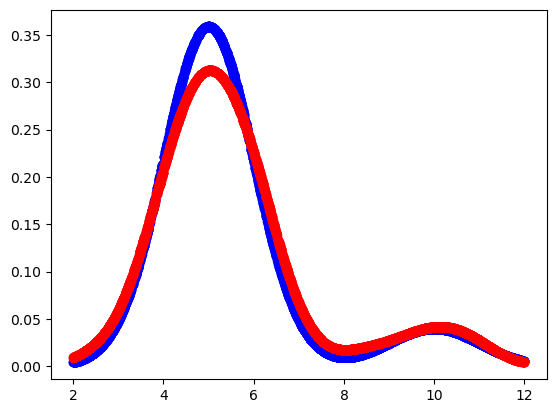

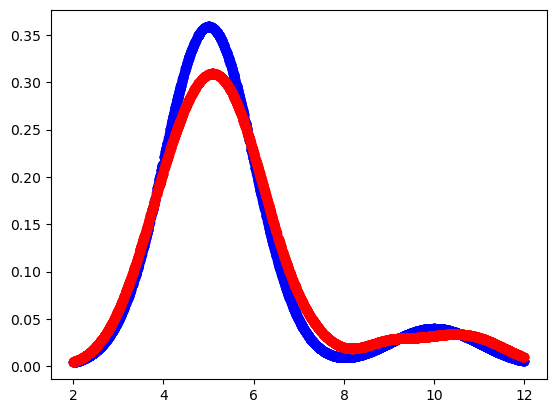

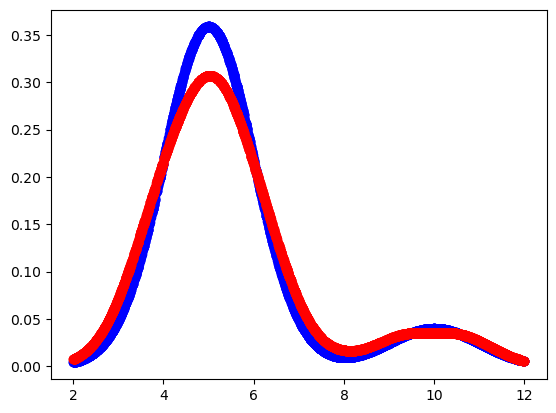

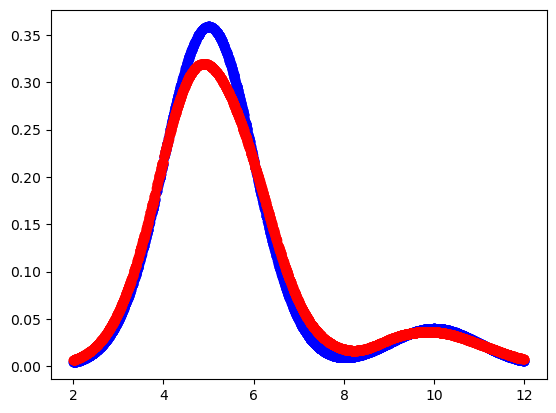

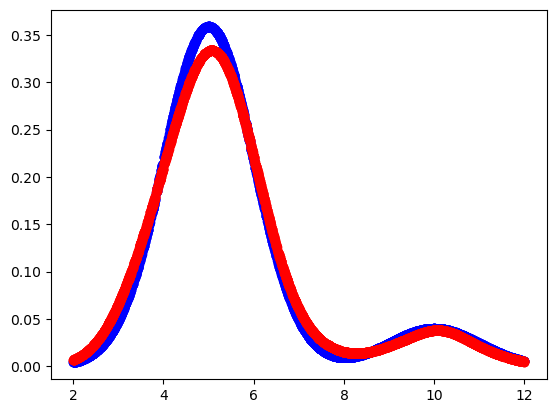

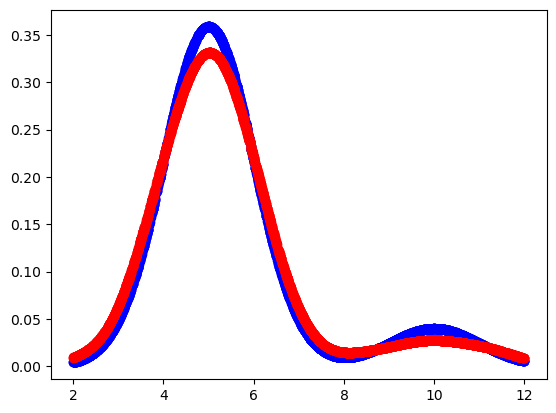

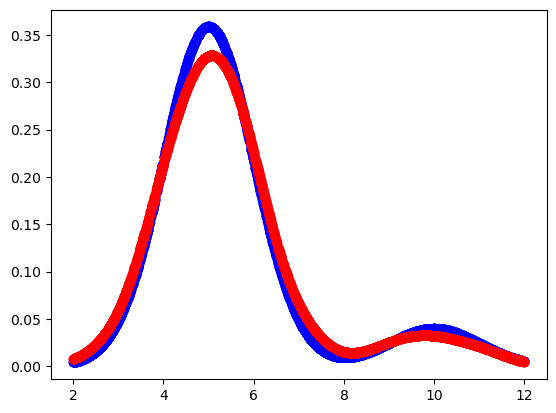

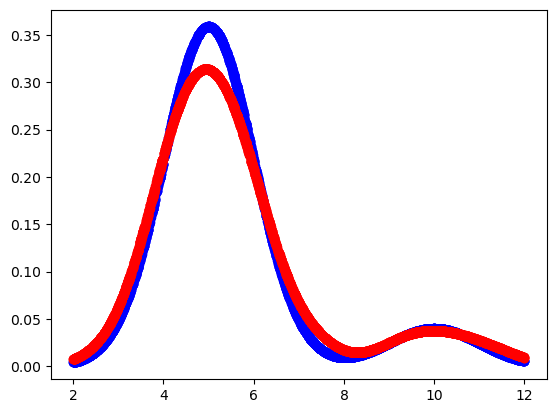

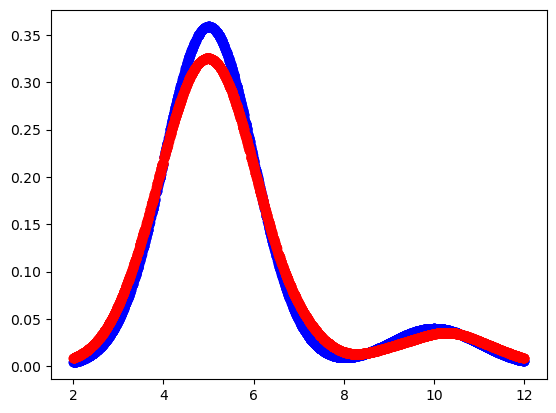

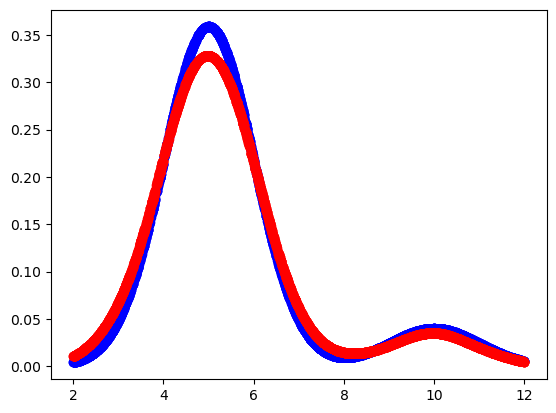

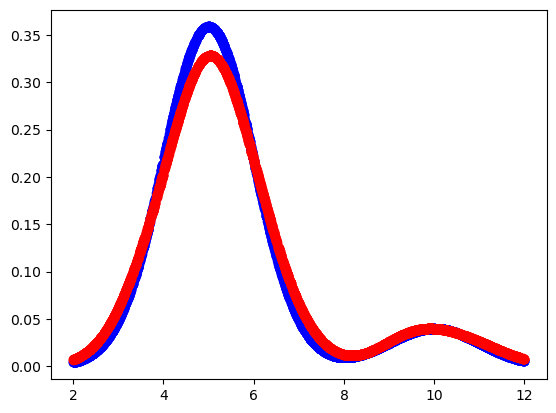

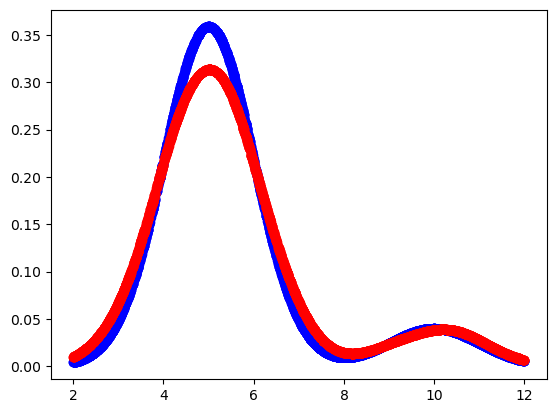

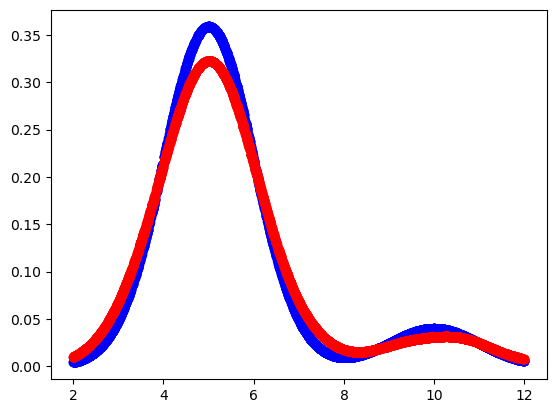

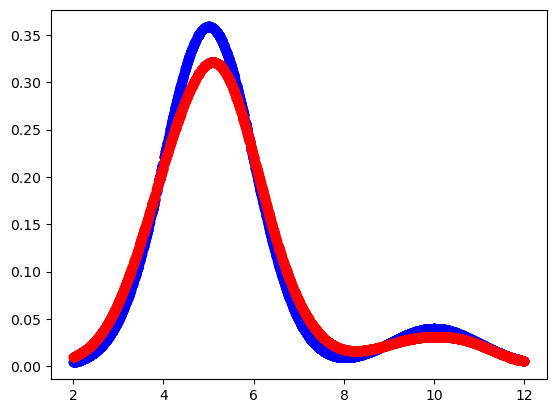

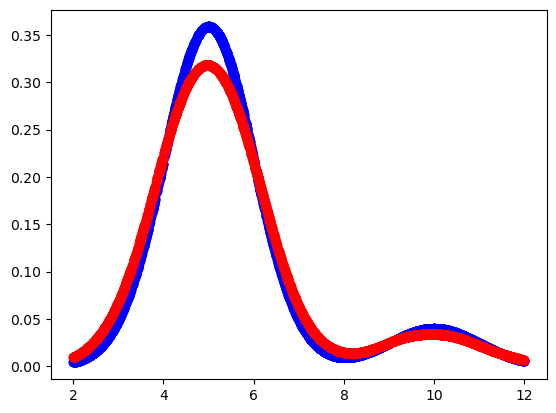

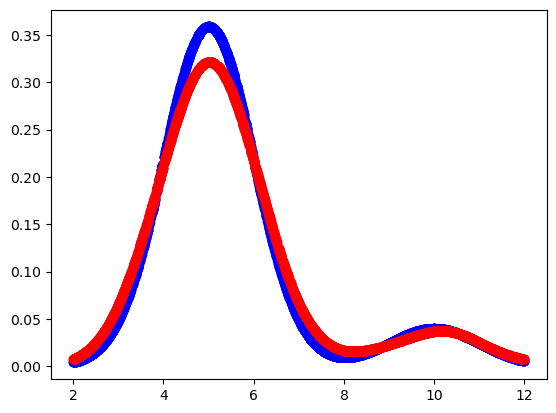

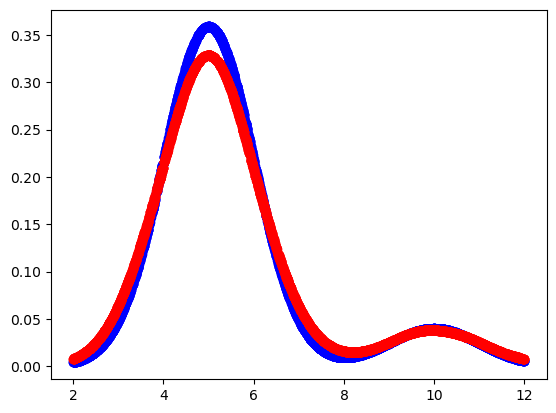

In [9]:
x=np.random.uniform(2,12,3000)
for i in range(20):
    samp=draw_gaussian_mixture(5,1,10,1,0.9,200*(i+1))
    kde=fit_kde(samp,"gaussian",0.5)
    x=np.array(x)
    log_dens=kde.score_samples(x.reshape(-1,1))
    dens=np.exp(log_dens)
    true_dens=mixture_density(x,5,1,10,1,0.9)
    plt.scatter(x,true_dens,color="blue")
    plt.scatter(x,dens,color="red")
    plt.show()



In [7]:
samp1=draw_gaussian_mixture(5,1,10,1,0.9,200)

(array([ 1.,  1.,  3.,  2., 12., 17., 33., 33., 37., 13., 10.,  7.,  1.,
         1.,  1.,  6.,  2.,  7., 10.,  3.]),
 array([ 1.25376106,  1.74952731,  2.24529357,  2.74105983,  3.23682609,
         3.73259234,  4.2283586 ,  4.72412486,  5.21989112,  5.71565737,
         6.21142363,  6.70718989,  7.20295615,  7.6987224 ,  8.19448866,
         8.69025492,  9.18602118,  9.68178743, 10.17755369, 10.67331995,
        11.16908621]),
 <BarContainer object of 20 artists>)

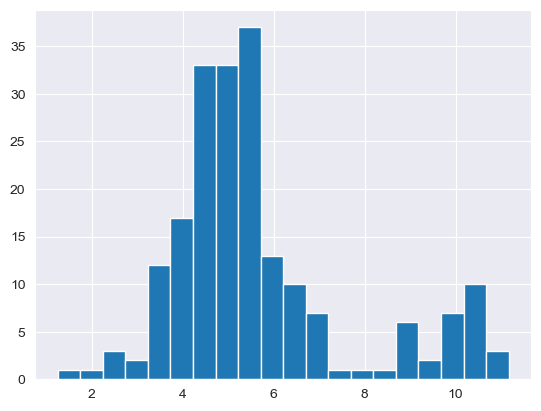

In [8]:
plt.hist(samp1,20)

In [23]:
x=np.random.uniform(2,12,400)

In [10]:
samp2=draw_gaussian_mixture(5,1,10,1,0.9,200)

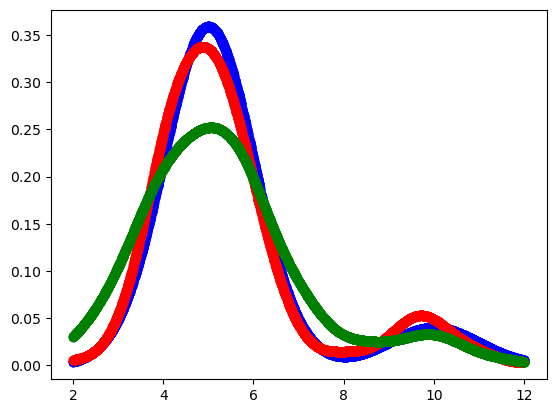

In [11]:
k=1000
x=np.random.randint(0,200,k)
eps=np.random.normal(0,1,k)
samp2a=np.zeros(k)
for i in range(k):
    samp2a[i]=samp2[x[i]]+eps[i]
kde1=fit_kde(samp2,"gaussian",0.5)
kde2=fit_kde(samp2a,"gaussian",0.5)
x0=np.random.uniform(2,12,4000)
x0=np.array(x0)
log_dens1=kde1.score_samples(x0.reshape(-1,1))
dens1=np.exp(log_dens1)
log_dens2=kde2.score_samples(x0.reshape(-1,1))
dens2=np.exp(log_dens2)
true_dens=mixture_density(x0,5,1,10,1,0.9)
plt.scatter(x0,true_dens,color="blue")
plt.scatter(x0,dens1,color="red")
plt.scatter(x0,dens2,color="green")
plt.show()